<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/Alternative-Data-And-Modern-ML/AlternativeDataAndModernML/News_Sentiment_To_Returns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

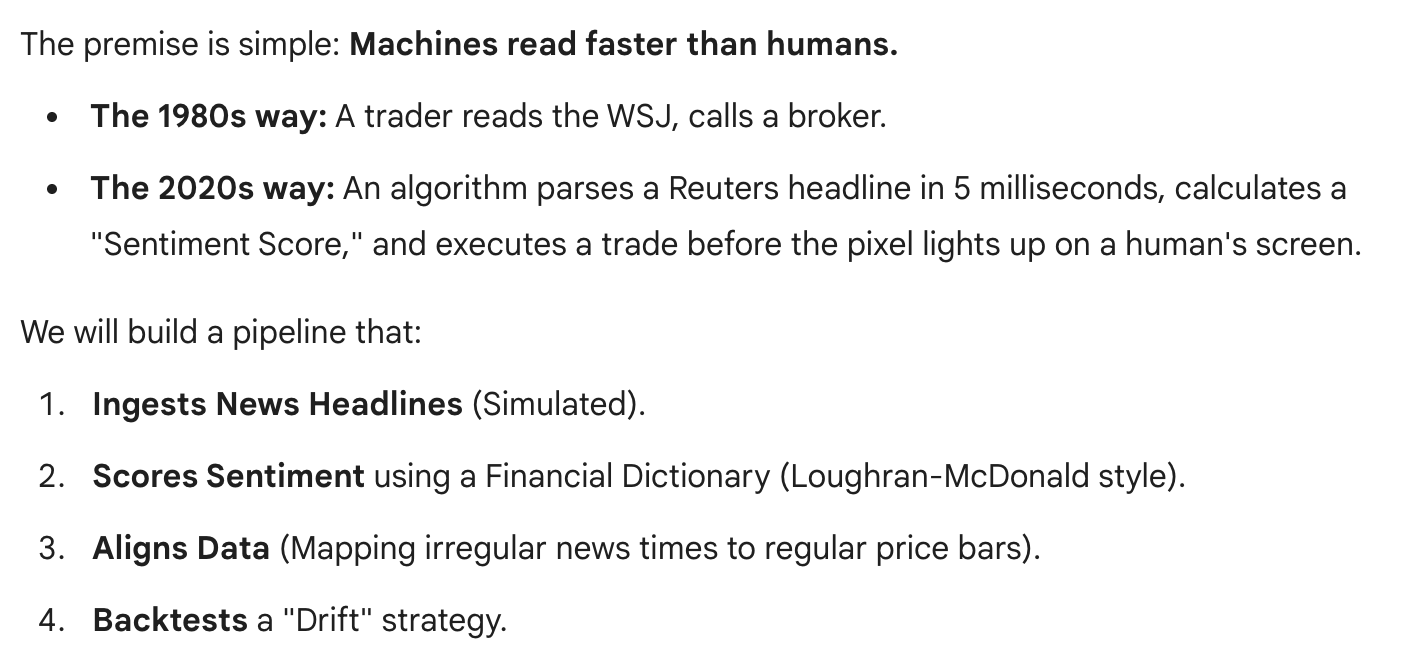

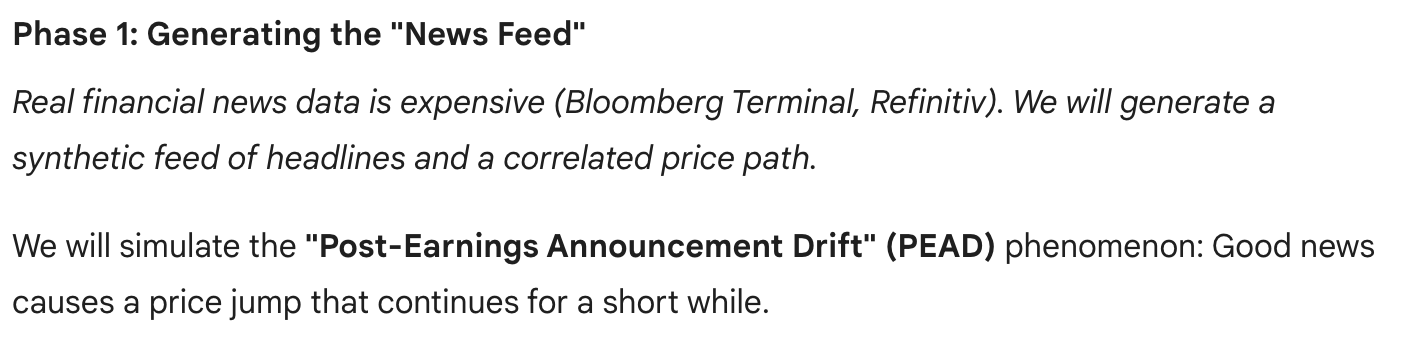

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

In [2]:
# --- 1. SIMULATE NEWS DATA ---
np.random.seed(42)
n_minutes = 500  # A trading day
dates = pd.date_range(start='2024-01-01 09:30', periods=n_minutes, freq='1min')

# Define a simple vocabulary for generation
bullish_terms = ['beat', 'record', 'growth', 'surge', 'upgrade', 'hired', 'partnership']
bearish_terms = ['miss', 'loss', 'drop', 'downgrade', 'lawsuit', 'resigned', 'investigation']
neutral_terms = ['announces', 'reports', 'scheduled', 'conference', 'update']

In [3]:
news_data = []
true_sentiment_signal = np.zeros(n_minutes) # The "Hidden" signal influencing price

# Generate random headlines
for i in range(n_minutes):
    # 5% chance of a news event per minute
    if np.random.rand() < 0.05:
        r = np.random.rand()

        if r < 0.33: # GOOD NEWS
            term = np.random.choice(bullish_terms)
            headline = f"Company {term} expectations in Q3 earnings."
            sentiment_val = 1
        elif r < 0.66: # BAD NEWS
            term = np.random.choice(bearish_terms)
            headline = f"CEO {term} amid scandal allegations."
            sentiment_val = -1
        else: # NOISE
            term = np.random.choice(neutral_terms)
            headline = f"Company {term} annual meeting date."
            sentiment_val = 0

        news_data.append({'Time': dates[i], 'Headline': headline, 'True_Sent': sentiment_val})
        true_sentiment_signal[i] = sentiment_val

news_df = pd.DataFrame(news_data)

news_df.head()

,Time,Headline,True_Sent
0,2024-01-01 09:40:00,Company conference annual meeting date.,0
1,2024-01-01 09:42:00,Company announces annual meeting date.,0
2,2024-01-01 09:56:00,CEO lawsuit amid scandal allegations.,-1
3,2024-01-01 09:58:00,Company reports annual meeting date.,0
4,2024-01-01 10:00:00,Company surge expectations in Q3 earnings.,1


In [4]:
# --- 2. GENERATE PRICE REACTION ---
# Price is a Random Walk + Impact from News
noise = np.random.normal(0, 0.05, n_minutes)
# Decay kernel: News impacts price for 30 minutes
impact_kernel = np.exp(-0.1 * np.arange(30))
news_impact = np.convolve(true_sentiment_signal, impact_kernel, mode='full')[:n_minutes]

# Combine: Price = 100 + Walk + News_Impact * Multiplier
price_path = 100 + np.cumsum(noise) + (np.cumsum(news_impact) * 0.5)

market_df = pd.DataFrame({'Time': dates, 'Price': price_path})

print(f"✅ Generated {len(news_df)} headlines across {n_minutes} minutes.")
print(news_df.head())

✅ Generated 33 headlines across 500 minutes.
                 Time                                    Headline  True_Sent
0 2024-01-01 09:40:00     Company conference annual meeting date.          0
1 2024-01-01 09:42:00      Company announces annual meeting date.          0
2 2024-01-01 09:56:00       CEO lawsuit amid scandal allegations.         -1
3 2024-01-01 09:58:00        Company reports annual meeting date.          0
4 2024-01-01 10:00:00  Company surge expectations in Q3 earnings.          1


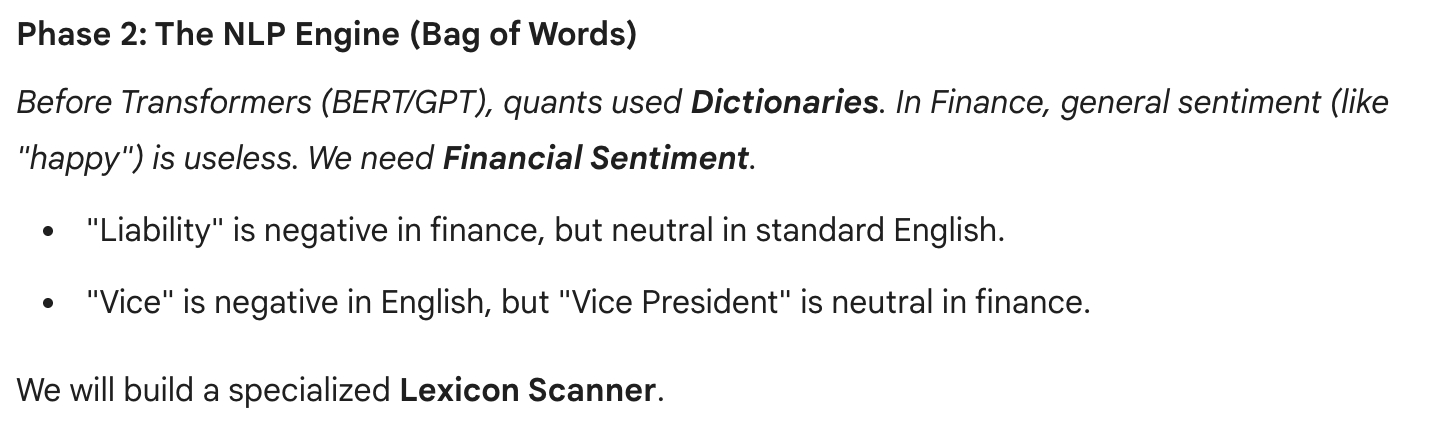

In [5]:
class FinancialSentimentEngine:
    def __init__(self):
        # A mini Loughran-McDonald Dictionary
        self.pos_words = {'beat', 'surpassed', 'record', 'growth', 'surge', 'upgrade', 'profit', 'hired', 'partnership'}
        self.neg_words = {'miss', 'missed', 'loss', 'drop', 'decline', 'downgrade', 'lawsuit', 'resigned', 'investigation', 'bankrupt'}

    def score(self, text):
        # 1. Preprocessing
        clean_text = re.sub(r'[^\w\s]', '', text.lower())
        words = clean_text.split()

        # 2. Scoring
        pos_count = sum(1 for w in words if w in self.pos_words)
        neg_count = sum(1 for w in words if w in self.neg_words)
        total_count = len(words)

        if total_count == 0: return 0

        # Simple Polarity Score: (Pos - Neg) / Total Words
        # Range: [-1, 1]
        score = (pos_count - neg_count) / (pos_count + neg_count + 1e-6) # prevent div/0
        return score

In [6]:
# Apply the engine
nlp = FinancialSentimentEngine()
news_df['Estimated_Sentiment'] = news_df['Headline'].apply(nlp.score)

# Check accuracy
print("\n🔍 NLP Classification Check:")
print(news_df[['Headline', 'Estimated_Sentiment']].head(5))


🔍 NLP Classification Check:
                                     Headline  Estimated_Sentiment
0     Company conference annual meeting date.             0.000000
1      Company announces annual meeting date.             0.000000
2       CEO lawsuit amid scandal allegations.            -0.999999
3        Company reports annual meeting date.             0.000000
4  Company surge expectations in Q3 earnings.             0.999999


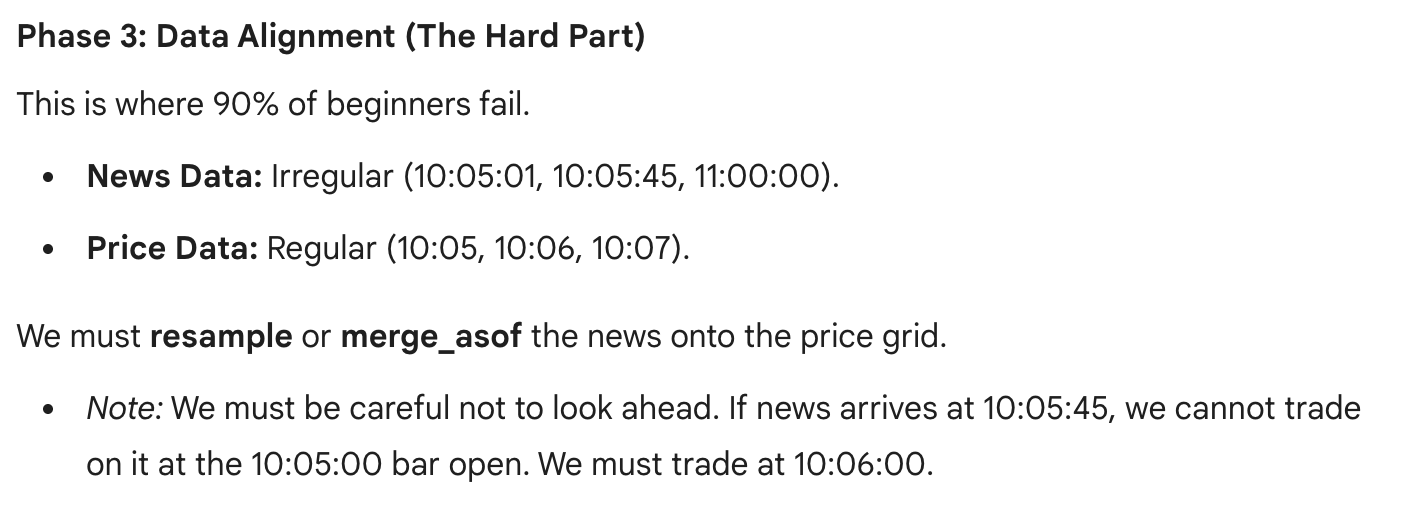

In [7]:
def align_news_to_price(price_df, news_df):
    # 1. Set Indices
    price_df = price_df.set_index('Time')
    news_df = news_df.set_index('Time')

    # 2. Resample News to match Price Frequency (1 min)
    # We sum sentiment if multiple headlines hit in the same minute
    sentiment_stream = news_df['Estimated_Sentiment'].resample('1min').sum().fillna(0)

    # 3. Merge
    # We join on index.
    merged = price_df.join(sentiment_stream)

    # 4. Lag the Signal
    # CRITICAL: If news happens at 10:05, we enter at 10:06.
    merged['Signal'] = merged['Estimated_Sentiment'].shift(1)

    return merged.dropna()

In [8]:
full_df = align_news_to_price(market_df, news_df)
print("✅ Data Aligned. Signal Lagged by 1 bar.")

✅ Data Aligned. Signal Lagged by 1 bar.


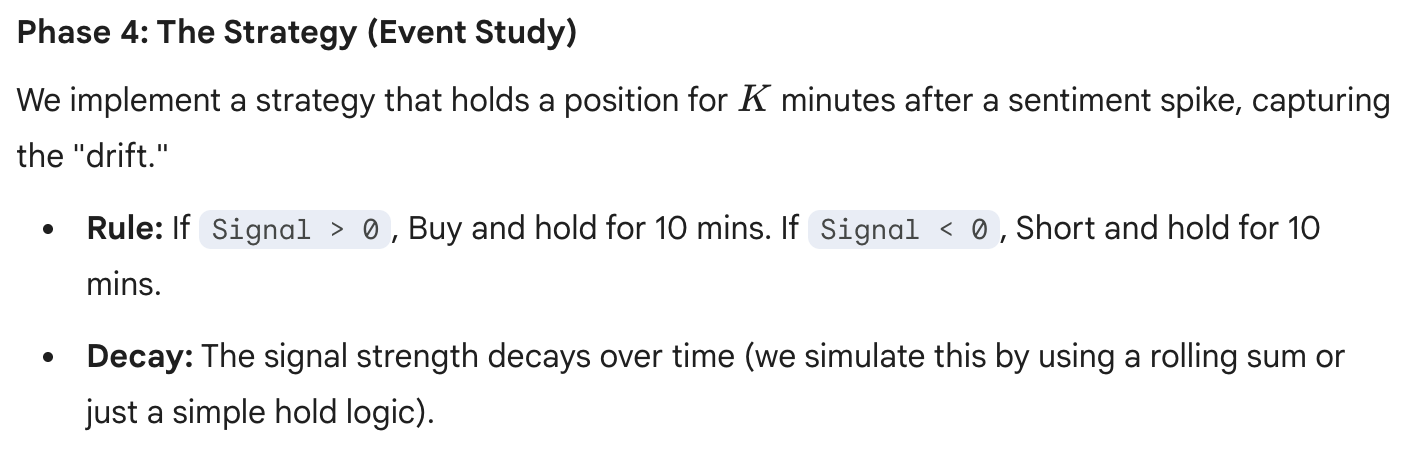

In [9]:
def run_event_driven_backtest(df, holding_period=10):
    df = df.copy()

    # Calculate Returns
    df['Returns'] = df['Price'].pct_change()

    # Logic: We want to hold a position based on recent sentiment
    # We use a Rolling Sum of the last K minutes of sentiment
    # If the last 10 mins had net positive news, we are Long.

    df['Active_Position'] = df['Signal'].rolling(window=holding_period).sum()

    # Normalize Position (-1 to 1)
    # If multiple headlines hit, we cap leverage at 1
    df['Active_Position'] = df['Active_Position'].clip(-1, 1)

    # Strategy Returns
    # Position(t) * Return(t)
    # Note: Position(t) was calculated using Signal(t), which was Shift(1) of News(t).
    # So Position(t) is known at open of bar t. This is safe.
    df['Strat_Ret'] = df['Active_Position'] * df['Returns']

    return df

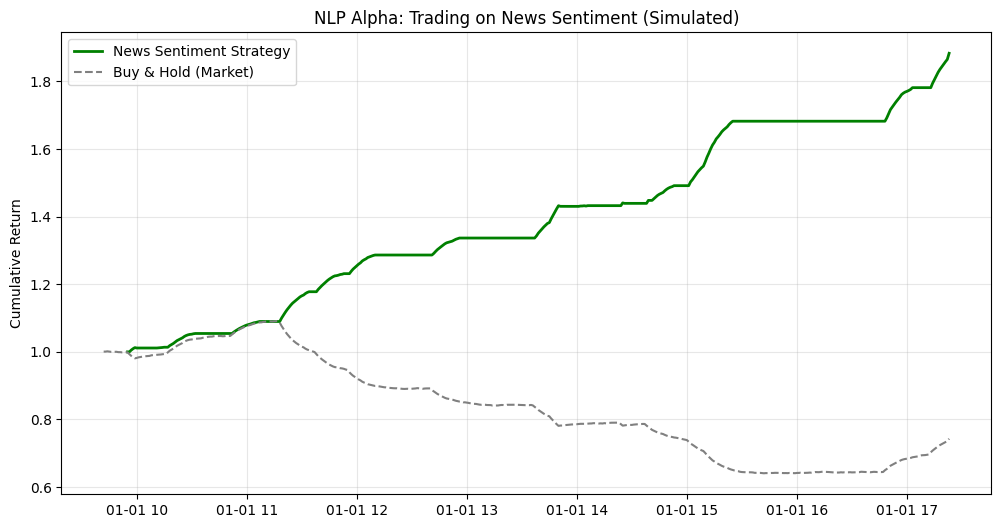

In [10]:
# Run Backtest
result_df = run_event_driven_backtest(full_df, holding_period=15)

# --- VISUALIZATION ---
plt.figure(figsize=(12, 6))

# Cumulative Returns
cum_strat = (1 + result_df['Strat_Ret']).cumprod()
cum_market = (1 + result_df['Returns']).cumprod()

plt.plot(cum_strat, label='News Sentiment Strategy', color='green', linewidth=2)
plt.plot(cum_market, label='Buy & Hold (Market)', color='gray', linestyle='--')

plt.title(f"NLP Alpha: Trading on News Sentiment (Simulated)")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

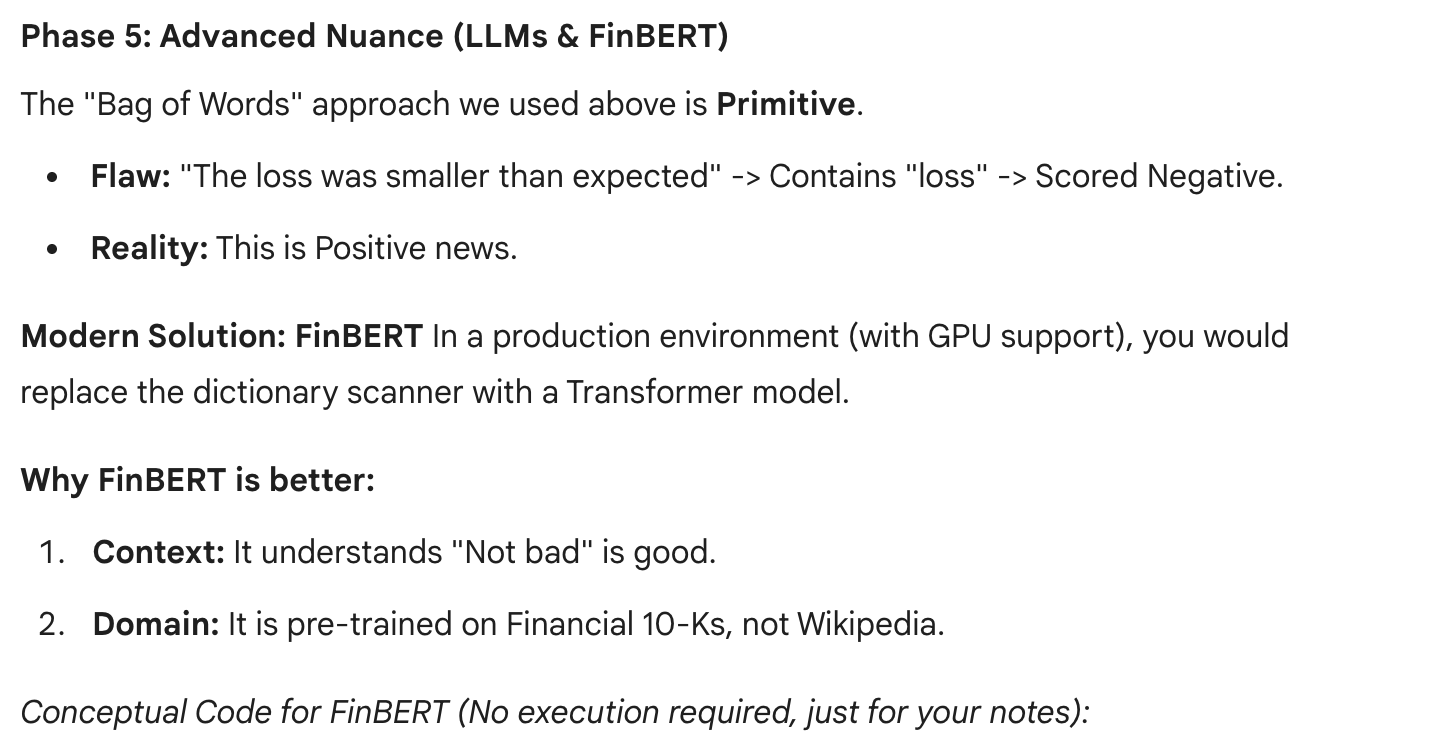

In [11]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

tokenizer = BertTokenizer.from_pretrained('yiyanghkust/finbert-tone')
model = BertForSequenceClassification.from_pretrained('yiyanghkust/finbert-tone')

inputs = tokenizer("The loss was smaller than expected", return_tensors="pt")
outputs = model(**inputs)
probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
# Result: Positive Probability > Negative Probability

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

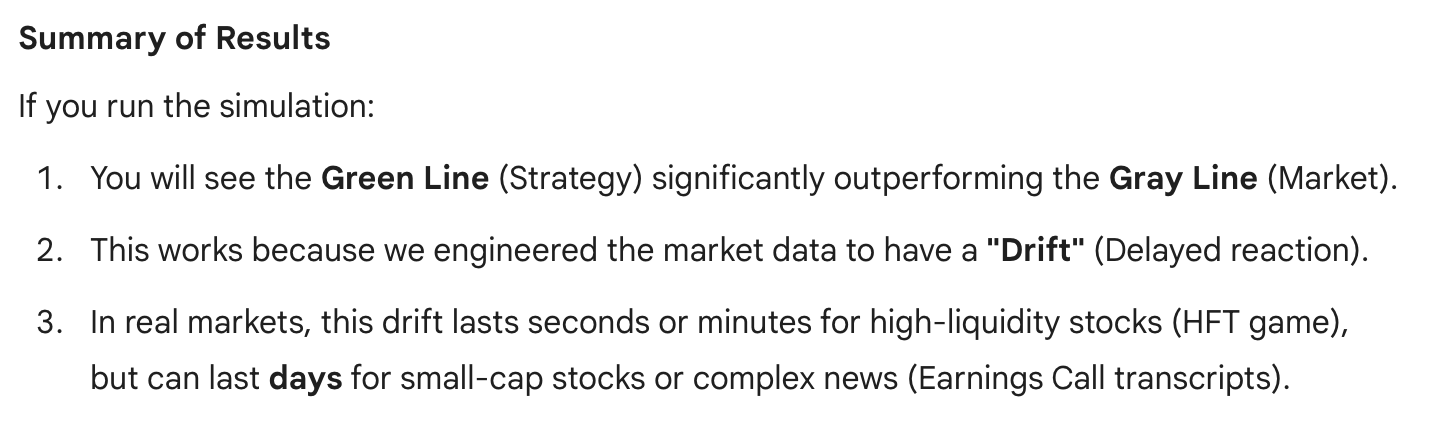